In [2]:

import os
import pickle
from dataclasses import dataclass
from pathlib import Path

import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm


from PIL import Image
from mediapipe.tasks import python
from mediapipe.tasks.python import vision


MODEL_PATH = "models/face_landmarker.task"

@dataclass
class FaceRoiConfig:
    eye_dilate_ksize: int = 9
    lips_dilate_ksize: int = 11
    brow_dilate_ksize: int = 9
    clip_limit: float = 2.0
    tile_grid_size: tuple = (8, 8)

FACE_OVAL_IDX = [
    10,338,297,332,284,251,389,356,454,323,
    361,288,397,365,379,378,400,377,152,
    148,176,149,150,136,172,58,132,93,
    234,127,162,21,54,103,67,109
]

OUTER_LIPS_IDX = [
    61,146,91,181,84,17,314,405,321,375,291,
    409,270,269,267,0,37,39,40,185
]

LEFT_EYE_IDX = [33,160,158,133,153,144]
RIGHT_EYE_IDX = [362,385,387,263,373,380]

LEFT_EYEBROW_IDX = [70, 63, 105, 66, 107, 55, 65, 52, 53, 46]
RIGHT_EYEBROW_IDX = [336, 296, 334, 293, 300, 285, 295, 282, 283, 276]


FEATURE_POLYGONS = {
    "face": FACE_OVAL_IDX,
    "lips": OUTER_LIPS_IDX,
    "left_eye": LEFT_EYE_IDX,
    "right_eye": RIGHT_EYE_IDX,
}


REGION_PATH_CANDIDATES = [
    "utils/media_pipe_regions.pkl",
]

DEFAULT_FACE_REGIONS = ["cheeks", "bottom-face", "forehead", "under-eyes"]


img_dir = Path("data\images_wrinkles")
mask_dir = Path("data\manual_wrinkle_masks")


def create_face_landmarker(model_path=MODEL_PATH, num_faces=1):
    base_options = python.BaseOptions(model_asset_path=model_path)
    options = vision.FaceLandmarkerOptions(
        base_options=base_options,
        output_face_blendshapes=False,
        output_facial_transformation_matrixes=False,
        num_faces=num_faces,
    )
    return vision.FaceLandmarker.create_from_options(options)


detector = create_face_landmarker(MODEL_PATH)
image_paths = sorted(img_dir.glob("*.png"))

pairs = []

for img_path in image_paths:
    mask_path = mask_dir / img_path.name
    
    if mask_path.exists():
        pairs.append((img_path, mask_path))
    else:
        print(f"⚠ Mask not found for {img_path.name}")

print(f"Recovered {len(pairs)} pairs successfully.")
pairs[:3]

<>:63: SyntaxWarning: invalid escape sequence '\i'
<>:64: SyntaxWarning: invalid escape sequence '\m'
<>:63: SyntaxWarning: invalid escape sequence '\i'
<>:64: SyntaxWarning: invalid escape sequence '\m'
C:\Users\mpele\AppData\Local\Temp\ipykernel_16596\102635196.py:63: SyntaxWarning: invalid escape sequence '\i'
  img_dir = Path("data\images_wrinkles")
C:\Users\mpele\AppData\Local\Temp\ipykernel_16596\102635196.py:64: SyntaxWarning: invalid escape sequence '\m'
  mask_dir = Path("data\manual_wrinkle_masks")


Recovered 1000 pairs successfully.


[(WindowsPath('data/images_wrinkles/00001.png'),
  WindowsPath('data/manual_wrinkle_masks/00001.png')),
 (WindowsPath('data/images_wrinkles/00011.png'),
  WindowsPath('data/manual_wrinkle_masks/00011.png')),
 (WindowsPath('data/images_wrinkles/00016.png'),
  WindowsPath('data/manual_wrinkle_masks/00016.png'))]

In [3]:
cfg = FaceRoiConfig(
    eye_dilate_ksize=9,
    lips_dilate_ksize=11,
    brow_dilate_ksize=9,
    clip_limit=1.5,
    tile_grid_size=(8, 8),)

## **Detecting Facial Target Regions**

In [4]:

def read_rgb_image(image_or_path):
    if isinstance(image_or_path, (str, Path)):
        return np.array(Image.open(image_or_path).convert("RGB"))
    return np.asarray(image_or_path).copy()


def detect_face_landmarks(img_rgb, detector=detector):
    h, w = img_rgb.shape[:2]
    mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
    result = detector.detect(mp_image)

    if not result.face_landmarks:
        return None, h, w
    return result.face_landmarks[0], h, w


def landmarks_to_polygon(face_landmarks, indices, h, w):
    pts = []
    for idx in indices:
        lm = face_landmarks[idx]
        pts.append([int(lm.x * w), int(lm.y * h)])
    return np.array(pts, dtype=np.int32)


def polygon_to_mask(img_shape, polygon):
    mask = np.zeros(img_shape[:2], dtype=np.uint8)
    cv2.fillPoly(mask, [polygon], 1)
    return mask


def maybe_convex_hull(polygon):
    return cv2.convexHull(polygon) if len(polygon) >= 3 else polygon


def dilate_mask(mask, ksize):
    if ksize is None or ksize <= 1:
        return mask
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
    return cv2.dilate(mask, kernel, iterations=1)


def overlay_mask(img_rgb, mask, color=(255, 0, 0), alpha=0.35):
    out = img_rgb.copy()
    color_img = np.zeros_like(out)
    color_img[..., 0] = color[0]
    color_img[..., 1] = color[1]
    color_img[..., 2] = color[2]

    mask_3d = (mask > 0)[..., None]
    blended = ((1 - alpha) * out + alpha * color_img).astype(np.uint8)
    out[mask_3d.squeeze(-1)] = blended[mask_3d.squeeze(-1)]
    return out


def draw_polygon(img_rgb, polygon, color=(0, 255, 0), thickness=2):
    out = img_rgb.copy()
    cv2.polylines(out, [polygon], isClosed=True, color=color, thickness=thickness)
    return out


def apply_mask_to_image(img_rgb, mask, fill_value=0):
    out = img_rgb.copy()
    out[mask == 0] = fill_value
    return out


def build_feature_polygons(face_landmarks, h, w):
    polygons = {}
    for name, indices in FEATURE_POLYGONS.items():
        poly = landmarks_to_polygon(face_landmarks, indices, h, w)
        if name != "face":
            poly = maybe_convex_hull(poly)
        polygons[name] = poly
    return polygons


def build_feature_masks(img_shape, polygons, cfg):
    masks = {}
    masks["face"] = polygon_to_mask(img_shape, polygons["face"])
    masks["lips"] = dilate_mask(polygon_to_mask(img_shape, polygons["lips"]), cfg.lips_dilate_ksize)
    masks["left_eye"] = dilate_mask(polygon_to_mask(img_shape, polygons["left_eye"]), cfg.eye_dilate_ksize)
    masks["right_eye"] = dilate_mask(polygon_to_mask(img_shape, polygons["right_eye"]), cfg.eye_dilate_ksize)
    
    masks["eyes"] = np.clip(masks["left_eye"] + masks["right_eye"], 0, 1).astype(np.uint8)
    masks["excluded"] = np.clip(masks["lips"] + masks["eyes"], 0, 1).astype(np.uint8)
    masks["clean_roi"] = np.clip(masks["face"] - masks["excluded"], 0, 1).astype(np.uint8)
    return masks


def build_clean_face_roi(image_or_path, detector=detector, cfg=None):
    cfg = cfg or FaceRoiConfig()
    img_rgb = read_rgb_image(image_or_path)

    face_landmarks, h, w = detect_face_landmarks(img_rgb, detector=detector)
    if face_landmarks is None:
        return {
            "status": "no_face",
            "image": img_rgb,
        }

    polygons = build_feature_polygons(face_landmarks, h, w)
    masks = build_feature_masks(img_rgb.shape, polygons, cfg)

    clean_roi_only = apply_mask_to_image(img_rgb, masks["clean_roi"], fill_value=0)

    return {
        "status": "ok",
        "image": img_rgb,
        "clean_roi_only": clean_roi_only,
        "polygons": polygons,
        "masks": masks,
        "shape": (h, w),
    }

# =========================================================
# REGION LOADING / POLYGONS / MASKS
# =========================================================
def load_region_landmarks_dict(path=None, candidates=None):
    candidates = list(candidates or [])
    if path is not None:
        candidates = [path] + candidates
    candidates += REGION_PATH_CANDIDATES

    checked = []
    for p in candidates:
        if p is None:
            continue
        checked.append(str(p))
        if os.path.exists(p):
            with open(p, "rb") as f:
                data = pickle.load(f)
            if not isinstance(data, dict):
                raise ValueError(f"Region landmarks file must contain a dict, got {type(data)}")
            return data, p

    raise FileNotFoundError(
        "Could not find region-landmarks pickle. Checked:\n" + "\n".join(checked)
    )


def normalize_region_indices(indices):
    arr = np.asarray(indices).reshape(-1).tolist()
    return [int(x) for x in arr]


def sort_points_as_polygon(points):
    pts = np.asarray(points, dtype=np.float32)
    if len(pts) <= 2:
        return pts.astype(np.int32)
    center = pts.mean(axis=0)
    angles = np.arctan2(pts[:, 1] - center[1], pts[:, 0] - center[0])
    order = np.argsort(angles)
    return pts[order].astype(np.int32)


def build_closed_cheek_contours(face_landmarks, indices, h, w):
    """
    Split cheeks into left/right and build one closed contour per cheek.
    This avoids filling the bridge through the nose.
    """
    pts = landmarks_to_polygon(face_landmarks, indices, h, w)

    if len(pts) < 6:
        poly = maybe_convex_hull(sort_points_as_polygon(pts))
        poly = np.asarray(poly, dtype=np.int32).reshape(-1, 2)
        if len(poly) >= 3 and not np.array_equal(poly[0], poly[-1]):
            poly = np.vstack([poly, poly[0]])
        return {"left-cheek": poly}

    face_center_x = np.median([lm.x * w for lm in face_landmarks])
    left_pts = pts[pts[:, 0] < face_center_x]
    right_pts = pts[pts[:, 0] >= face_center_x]

    contours = {}
    for region_name, side_pts in [("left-cheek", left_pts), ("right-cheek", right_pts)]:
        if len(side_pts) < 3:
            continue

        poly = sort_points_as_polygon(side_pts)
        poly = maybe_convex_hull(poly)
        poly = np.asarray(poly, dtype=np.int32).reshape(-1, 2)

        if len(poly) >= 3 and not np.array_equal(poly[0], poly[-1]):
            poly = np.vstack([poly, poly[0]])

        contours[region_name] = poly

    if len(contours) == 0:
        poly = maybe_convex_hull(sort_points_as_polygon(pts))
        poly = np.asarray(poly, dtype=np.int32).reshape(-1, 2)
        if len(poly) >= 3 and not np.array_equal(poly[0], poly[-1]):
            poly = np.vstack([poly, poly[0]])
        contours["left-cheek"] = poly

    return contours


def build_custom_region_polygons(face_landmarks, h, w, region_landmarks_dict, region_names=None):
    if region_names is None:
        region_names = list(region_landmarks_dict.keys())

    polygons = {}
    for region_name in region_names:
        if region_name not in region_landmarks_dict:
            raise KeyError(
                f"Region '{region_name}' not found in landmarks dict. "
                f"Available keys: {list(region_landmarks_dict.keys())}"
            )

        indices = normalize_region_indices(region_landmarks_dict[region_name])

        if region_name == "cheeks":
            cheek_contours = build_closed_cheek_contours(
                face_landmarks=face_landmarks,
                indices=indices,
                h=h,
                w=w,
            )
            polygons.update(cheek_contours)
        else:
            poly = landmarks_to_polygon(face_landmarks, indices, h, w)
            poly = maybe_convex_hull(poly)
            poly = np.asarray(poly, dtype=np.int32).reshape(-1, 2)
            if len(poly) >= 3 and not np.array_equal(poly[0], poly[-1]):
                poly = np.vstack([poly, poly[0]])
            polygons[region_name] = poly

    return polygons


def polygon_or_polygons_to_mask(img_shape, polygon_or_polygons):
    mask = np.zeros(img_shape[:2], dtype=np.uint8)

    if isinstance(polygon_or_polygons, (list, tuple)):
        for poly in polygon_or_polygons:
            poly = np.asarray(poly, dtype=np.int32).reshape(-1, 2)
            if len(poly) >= 3:
                cv2.fillPoly(mask, [poly], 1)
    else:
        poly = np.asarray(polygon_or_polygons, dtype=np.int32).reshape(-1, 2)
        if len(poly) >= 3:
            cv2.fillPoly(mask, [poly], 1)

    return mask


def build_custom_region_masks(img_shape, region_polygons, base_masks=None, dilate_ksize=None):
    masks = {}
    clean_roi = None if base_masks is None else base_masks.get("clean_roi", None)

    for region_name, poly in region_polygons.items():
        mask = polygon_or_polygons_to_mask(img_shape, poly)

        if dilate_ksize is not None and dilate_ksize > 1:
            mask = dilate_mask(mask, dilate_ksize)

        if clean_roi is not None:
            mask = (mask * (clean_roi > 0)).astype(np.uint8)

        masks[region_name] = (mask > 0).astype(np.uint8)

    return masks


def colorize_masks_on_image(img_rgb, masks, alpha=0.30):
    palette = [
        (255, 80, 80),
        (80, 180, 255),
        (120, 220, 120),
        (255, 190, 80),
        (220, 120, 255),
        (120, 255, 220),
    ]
    out = img_rgb.copy()

    for i, (name, mask) in enumerate(masks.items()):
        color = palette[i % len(palette)]
        out = overlay_mask(out, mask, color=color, alpha=alpha)

        ys, xs = np.where(mask > 0)
        if len(xs) > 0:
            x = int(np.mean(xs))
            y = int(np.mean(ys))
            cv2.putText(
                out,
                name,
                (x - 35, y),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                color,
                2,
                cv2.LINE_AA,
            )
    return out


def to_uint8(img):
    if img.dtype == np.uint8:
        return img
    img = np.clip(img, 0, 255)
    return img.astype(np.uint8)


def rgb2gray(img_rgb):
    img_rgb = to_uint8(img_rgb)
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)


def erode_mask(mask, ksize=9, iterations=1):
    mask_u8 = (mask > 0).astype(np.uint8) * 255
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (ksize, ksize))
    eroded = cv2.erode(mask_u8, kernel, iterations=iterations)
    return (eroded > 0).astype(np.uint8)


def smooth_inside_mask(img_rgb, mask, sigma=2.0):
    """
    Gaussian smoothing only inside mask, without ugly black-border leakage.
    Uses normalized convolution.
    """
    img = img_rgb.astype(np.float32)
    m = (mask > 0).astype(np.float32)

    # kernel size from sigma
    k = int(max(3, 2 * round(3 * sigma) + 1))

    out = np.zeros_like(img, dtype=np.float32)

    denom = cv2.GaussianBlur(m, (k, k), sigmaX=sigma, sigmaY=sigma)
    denom = np.clip(denom, 1e-6, None)

    for c in range(3):
        num = cv2.GaussianBlur(img[..., c] * m, (k, k), sigmaX=sigma, sigmaY=sigma)
        out[..., c] = num / denom

    out *= m[..., None]
    return np.clip(out, 0, 255).astype(np.uint8)


def local_std_map(gray, win=15):
    """
    Local standard deviation map.
    """
    gray_f = gray.astype(np.float32)
    mean = cv2.blur(gray_f, (win, win))
    mean_sq = cv2.blur(gray_f ** 2, (win, win))
    var = np.clip(mean_sq - mean ** 2, 0, None)
    return np.sqrt(var)


def texture_evenness_metrics(img_rgb, mask, local_win=15, mask_erode_ksize=9):
    
    gray = rgb2gray(img_rgb)
    valid = erode_mask(mask, ksize=mask_erode_ksize, iterations=1)

    ys, xs = np.where(valid > 0)
    if len(xs) == 0:
        return {
            "n_pixels": 0,
            "intensity_std": np.nan,
            "local_std_mean": np.nan,
            "laplacian_abs_mean": np.nan,
            "gradient_mean": np.nan,
            "evenness_score": np.nan,
        }

    # local std
    lstd = local_std_map(gray, win=local_win)

    # Laplacian
    lap = cv2.Laplacian(gray.astype(np.float32), cv2.CV_32F, ksize=3)
    lap_abs = np.abs(lap)

    # Sobel gradient magnitude
    gx = cv2.Sobel(gray.astype(np.float32), cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray.astype(np.float32), cv2.CV_32F, 0, 1, ksize=3)
    grad = np.sqrt(gx ** 2 + gy ** 2)

    pix = gray[valid > 0].astype(np.float32)
    lstd_vals = lstd[valid > 0]
    lap_vals = lap_abs[valid > 0]
    grad_vals = grad[valid > 0]

    intensity_std = float(np.std(pix))
    local_std_mean = float(np.mean(lstd_vals))
    laplacian_abs_mean = float(np.mean(lap_vals))
    gradient_mean = float(np.mean(grad_vals))

    # simple interpretable score:
    # more texture detail / more local variation => lower evenness
    raw_roughness = (
        0.45 * local_std_mean +
        0.35 * laplacian_abs_mean +
        0.20 * gradient_mean
    )
    evenness_score = float(1.0 / (1.0 + raw_roughness))

    return {
        "n_pixels": int((valid > 0).sum()),
        "intensity_std": intensity_std,
        "local_std_mean": local_std_mean,
        "laplacian_abs_mean": laplacian_abs_mean,
        "gradient_mean": gradient_mean,
        "evenness_score": evenness_score,
    }


def plot_texture_pipeline_row(images, titles, metrics_list=None, figsize=(18, 5)):
    n = len(images)
    fig, axes = plt.subplots(1, n, figsize=figsize)

    if n == 1:
        axes = [axes]

    for i, (ax, img, title) in enumerate(zip(axes, images, titles)):
        ax.imshow(img)
        ax.axis("off")

        if metrics_list is not None:
            m = metrics_list[i]
            score_txt = f'evenness={m["evenness_score"]:.4f}'
            lstd_txt = f'local_std={m["local_std_mean"]:.2f}'
            lap_txt = f'lap={m["laplacian_abs_mean"]:.2f}'
            ax.set_title(f"{title}\n{score_txt}\n{lstd_txt}, {lap_txt}", fontsize=11)
        else:
            ax.set_title(title, fontsize=11)

    plt.tight_layout()
    plt.show()


# =========================
# main pipeline
# =========================
def run_face_texture_smoothing_pipeline(
    image_or_path,
    detector=detector,
    cfg=None,
    sigma1=1.5,
    sigma2=2.5,
    local_win=15,
    mask_key="clean_roi",
    show=True,
):

    res = build_clean_face_roi(image_or_path, detector=detector, cfg=cfg)

    img_rgb = res["image"]
    masks = res["masks"]
    roi_mask = (masks[mask_key] > 0).astype(np.uint8)

    # original clean ROI
    roi0 = apply_mask_to_image(img_rgb, roi_mask, fill_value=0)

    # 1st smoothing
    roi1 = smooth_inside_mask(roi0, roi_mask, sigma=sigma1)

    # 2nd smoothing = smooth result of first pass
    roi2 = smooth_inside_mask(roi1, roi_mask, sigma=sigma2)

    # metrics
    metrics0 = texture_evenness_metrics(roi0, roi_mask, local_win=local_win)
    metrics1 = texture_evenness_metrics(roi1, roi_mask, local_win=local_win)
    metrics2 = texture_evenness_metrics(roi2, roi_mask, local_win=local_win)

    metrics_df = pd.DataFrame([
        {"version": "original_roi", **metrics0},
        {"version": f"smooth_1_sigma_{sigma1}", **metrics1},
        {"version": f"smooth_2_sigma_{sigma2}", **metrics2},
    ])

    if show:
        plot_texture_pipeline_row(
            images=[roi0, roi1, roi2],
            titles=[
                "Original ROI",
                f"Smooth x1 (σ={sigma1})",
                f"Smooth x2 (σ={sigma2})",
            ],
            metrics_list=[metrics0, metrics1, metrics2],
            figsize=(18, 5),
        )

        display(metrics_df)

    return {
        "status": "ok",
        "image": img_rgb,
        "roi_mask": roi_mask,
        "roi_original": roi0,
        "roi_smooth_1": roi1,
        "roi_smooth_2": roi2,
        "metrics_df": metrics_df,
        "polygons": res["polygons"],
        "masks": res["masks"],
    }

## **Evenness calculation functions**

In [5]:
# =========================================================
# METRIC HELPERS
# =========================================================
def masked_mean(arr, mask):
    vals = arr[mask > 0]
    if vals.size == 0:
        return np.nan
    return float(np.mean(vals))


def masked_std(arr, mask):
    vals = arr[mask > 0]
    if vals.size == 0:
        return np.nan
    return float(np.std(vals))


def rgb2gray(img_rgb):
    if img_rgb.dtype != np.uint8:
        img_rgb = np.clip(img_rgb, 0, 255).astype(np.uint8)
    return cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)


def local_std_map(gray, win=15):
    gray_f = gray.astype(np.float32)
    mean = cv2.blur(gray_f, (win, win))
    mean_sq = cv2.blur(gray_f ** 2, (win, win))
    var = np.clip(mean_sq - mean ** 2, 0, None)
    return np.sqrt(var)


def compute_filter_responses(
    gray,
    mask,
    mask_erode_ksize=9,
    gabor_ksize=21,
    gabor_sigma=4.0,
    gabor_lambda=8.0,
    gabor_gamma=0.5,
):
    """
    Computes:
      - Laplacian |abs|
      - LoG |abs|
      - Gabor responses at 0, 45, 90, 135 deg
    Returns scalar metrics + response maps.
    """
    gray_f = gray.astype(np.float32)
    valid = erode_mask(mask, ksize=mask_erode_ksize, iterations=1)

    if valid.sum() == 0:
        feats = {
            "laplacian_abs_mean": np.nan,
            "log_abs_mean": np.nan,
            "gabor_mean_0": np.nan,
            "gabor_mean_45": np.nan,
            "gabor_mean_90": np.nan,
            "gabor_mean_135": np.nan,
            "gabor_mean_all": np.nan,
            "gabor_anisotropy_std": np.nan,
            "gabor_anisotropy_range": np.nan,
        }
        maps = {
            "valid_mask": valid,
            "lap_abs": np.zeros_like(gray_f),
            "log_abs": np.zeros_like(gray_f),
            "gabor_maps": [np.zeros_like(gray_f) for _ in range(4)],
        }
        return feats, maps

    # Laplacian
    lap = cv2.Laplacian(gray_f, cv2.CV_32F, ksize=3)
    lap_abs = np.abs(lap)

    # LoG = Gaussian blur + Laplacian
    blur = cv2.GaussianBlur(gray_f, (0, 0), sigmaX=1.2, sigmaY=1.2)
    log_resp = cv2.Laplacian(blur, cv2.CV_32F, ksize=3)
    log_abs = np.abs(log_resp)

    # Gabor
    thetas = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
    gabor_means = {}
    gabor_maps = []

    for theta in thetas:
        kernel = cv2.getGaborKernel(
            ksize=(gabor_ksize, gabor_ksize),
            sigma=gabor_sigma,
            theta=theta,
            lambd=gabor_lambda,
            gamma=gabor_gamma,
            psi=0,
            ktype=cv2.CV_32F,
        )
        resp = cv2.filter2D(gray_f, cv2.CV_32F, kernel)
        resp_abs = np.abs(resp)
        gabor_maps.append(resp_abs)
        gabor_means[theta] = masked_mean(resp_abs, valid)

    gabor_vals = np.array(list(gabor_means.values()), dtype=np.float32)

    feats = {
        "laplacian_abs_mean": masked_mean(lap_abs, valid),
        "log_abs_mean": masked_mean(log_abs, valid),

        "gabor_mean_0": float(gabor_means[0]),
        "gabor_mean_45": float(gabor_means[np.pi / 4]),
        "gabor_mean_90": float(gabor_means[np.pi / 2]),
        "gabor_mean_135": float(gabor_means[3 * np.pi / 4]),

        "gabor_mean_all": float(np.nanmean(gabor_vals)),
        "gabor_anisotropy_std": float(np.nanstd(gabor_vals)),
        "gabor_anisotropy_range": float(np.nanmax(gabor_vals) - np.nanmin(gabor_vals)),
    }

    maps = {
        "valid_mask": valid,
        "lap_abs": lap_abs,
        "log_abs": log_abs,
        "gabor_maps": gabor_maps,
    }

    return feats, maps


def texture_evenness_metrics_extended(
    img_rgb,
    mask,
    local_win=15,
    mask_erode_ksize=9,
    gabor_ksize=21,
    gabor_sigma=4.0,
    gabor_lambda=8.0,
    gabor_gamma=0.5,
):
    """
    Extended texture metrics:
      - intensity_std
      - local_std_mean
      - gradient_mean
      - laplacian_abs_mean
      - log_abs_mean
      - gabor_mean_*
      - evenness_score

    evenness_score:
      higher = smoother / more even texture
    """
    gray = rgb2gray(img_rgb)
    valid = erode_mask(mask, ksize=mask_erode_ksize, iterations=1)

    if valid.sum() == 0:

        metrics = {
            "n_pixels": 0,
            "intensity_std": np.nan,
            "local_std_mean": np.nan,
            "gradient_mean": np.nan,
            "laplacian_abs_mean": np.nan,
            "log_abs_mean": np.nan,
            "gabor_mean_0": np.nan,
            "gabor_mean_45": np.nan,
            "gabor_mean_90": np.nan,
            "gabor_mean_135": np.nan,
            "gabor_mean_all": np.nan,
            "gabor_anisotropy_std": np.nan,
            "gabor_anisotropy_range": np.nan,
            "evenness_score": np.nan,

            "tone_std_L": np.nan,
            "tone_local_std_L": np.nan,
            "tone_range_p90_p10_L": np.nan,
            "tone_std_a": np.nan,
            "tone_std_b": np.nan,
            "tone_evenness_score": np.nan,
        }

        maps = {
            "valid_mask": valid,
            "lap_abs": np.zeros_like(gray, dtype=np.float32),
            "log_abs": np.zeros_like(gray, dtype=np.float32),
            "gabor_maps": [np.zeros_like(gray, dtype=np.float32) for _ in range(4)],
        }
        return metrics, maps

    # intensity std
    pix = gray[valid > 0].astype(np.float32)
    intensity_std = float(np.std(pix))

    # local std
    lstd = local_std_map(gray, win=local_win)
    local_std_mean = float(np.mean(lstd[valid > 0]))

    # gradient magnitude
    gx = cv2.Sobel(gray.astype(np.float32), cv2.CV_32F, 1, 0, ksize=3)
    gy = cv2.Sobel(gray.astype(np.float32), cv2.CV_32F, 0, 1, ksize=3)
    grad = np.sqrt(gx ** 2 + gy ** 2)
    gradient_mean = float(np.mean(grad[valid > 0]))

    # filter responses
    filter_feats, filter_maps = compute_filter_responses(
        gray=gray,
        mask=mask,
        mask_erode_ksize=mask_erode_ksize,
        gabor_ksize=gabor_ksize,
        gabor_sigma=gabor_sigma,
        gabor_lambda=gabor_lambda,
        gabor_gamma=gabor_gamma,
    )

    # roughness -> evenness
    roughness = (
        0.5 * filter_feats["laplacian_abs_mean"] +
        0.5 * filter_feats["gabor_mean_all"]
    )
    evenness_score = float(1.0 / (1.0 + roughness))

    metrics = {
        "n_pixels": int(valid.sum()),
        "intensity_std": intensity_std,
        "local_std_mean": local_std_mean,
        "gradient_mean": gradient_mean,
        "laplacian_abs_mean": filter_feats["laplacian_abs_mean"],
        "log_abs_mean": filter_feats["log_abs_mean"],
        "gabor_mean_0": filter_feats["gabor_mean_0"],
        "gabor_mean_45": filter_feats["gabor_mean_45"],
        "gabor_mean_90": filter_feats["gabor_mean_90"],
        "gabor_mean_135": filter_feats["gabor_mean_135"],
        "gabor_mean_all": filter_feats["gabor_mean_all"],
        "gabor_anisotropy_std": filter_feats["gabor_anisotropy_std"],
        "gabor_anisotropy_range": filter_feats["gabor_anisotropy_range"],
        "evenness_score": evenness_score,
    }

    # tone metrics
    tone_metrics = compute_tone_evenness_metrics(
        img_rgb=img_rgb,
        mask=mask,
        local_win=local_win,
        mask_erode_ksize=mask_erode_ksize,
    )
    metrics.update(tone_metrics)

    return metrics, filter_maps


def compute_region_evenness_for_versions(
    versions,
    region_masks,
    local_win=15,
    mask_erode_ksize=9,
    gabor_ksize=21,
    gabor_sigma=4.0,
    gabor_lambda=8.0,
    gabor_gamma=0.5,
):
    rows = []
    region_filter_maps = {}

    for version_name, img in versions.items():
        for region_name, region_mask in region_masks.items():
            metrics, fmap = texture_evenness_metrics_extended(
                img_rgb=img,
                mask=region_mask,
                local_win=local_win,
                mask_erode_ksize=mask_erode_ksize,
                gabor_ksize=gabor_ksize,
                gabor_sigma=gabor_sigma,
                gabor_lambda=gabor_lambda,
                gabor_gamma=gabor_gamma,
            )
            rows.append({
                "version": version_name,
                "region": region_name,
                **metrics,
            })
            region_filter_maps[(region_name, version_name)] = fmap

    return pd.DataFrame(rows), region_filter_maps


def compute_tone_evenness_metrics(img_rgb, mask, local_win=15, mask_erode_ksize=9):
    valid = erode_mask(mask, ksize=mask_erode_ksize, iterations=1)

    if valid.sum() == 0:
        return {
            "tone_std_L": np.nan,
            "tone_local_std_L": np.nan,
            "tone_range_p90_p10_L": np.nan,
            "tone_std_a": np.nan,
            "tone_std_b": np.nan,
            "tone_evenness_score": np.nan,
        }

    img_u8 = np.clip(img_rgb, 0, 255).astype(np.uint8)
    lab = cv2.cvtColor(img_u8, cv2.COLOR_RGB2LAB).astype(np.float32)

    L = lab[..., 0]
    a = lab[..., 1]
    b = lab[..., 2]

    L_vals = L[valid > 0]
    a_vals = a[valid > 0]
    b_vals = b[valid > 0]

    tone_std_L = float(np.std(L_vals))
    tone_std_a = float(np.std(a_vals))
    tone_std_b = float(np.std(b_vals))

    L_local_std = local_std_map(L, win=local_win)
    tone_local_std_L = float(np.mean(L_local_std[valid > 0]))

    p10 = float(np.percentile(L_vals, 10))
    p90 = float(np.percentile(L_vals, 90))
    tone_range_p90_p10_L = p90 - p10

    tone_roughness = (
        0.45 * tone_std_a +
        0.45 * tone_std_b
    )
    tone_evenness_score = float(1.0 / (1.0 + tone_roughness))

    return {
        "tone_std_L": tone_std_L,
        "tone_local_std_L": tone_local_std_L,
        "tone_range_p90_p10_L": tone_range_p90_p10_L,
        "tone_std_a": tone_std_a,
        "tone_std_b": tone_std_b,
        "tone_evenness_score": tone_evenness_score,
    }


# =========================================================
# MAIN PIPELINE
# =========================================================
def run_face_texture_smoothing_with_regions(
    image_or_path,
    detector=detector,
    cfg=None,
    sigma1=1.5,
    sigma2=2.5,
    local_win=15,
    mask_key="clean_roi",
    region_landmarks_path=None,
    region_names=None,
    region_dilate_ksize=None,
    show=True,
    mask_erode_ksize=9,
    gabor_ksize=21,
    gabor_sigma=4.0,
    gabor_lambda=8.0,
    gabor_gamma=0.5,
):
    cfg = cfg or FaceRoiConfig()

    res = build_clean_face_roi(image_or_path, detector=detector, cfg=cfg)
    if res["status"] != "ok":
        return {
            "status": res["status"],
            "image": image_or_path,
            "global_metrics_df": pd.DataFrame(),
            "region_metrics_df": pd.DataFrame(),
            "versions": {},
            "region_masks": {},
            "global_filter_maps": {},
            "region_filter_maps": {},
        }

    img_rgb = res["image"]
    masks = res["masks"]
    roi_mask = (masks[mask_key] > 0).astype(np.uint8)

    # whole-face ROI versions
    roi0 = apply_mask_to_image(img_rgb, roi_mask, fill_value=0)
    roi1 = smooth_inside_mask(roi0, roi_mask, sigma=sigma1)
    roi2 = smooth_inside_mask(roi1, roi_mask, sigma=sigma2)

    versions = {
        "original_roi": roi0,
        f"smooth_1_sigma_{sigma1}": roi1,
        f"smooth_2_sigma_{sigma2}": roi2,
    }

    # whole-face metrics
    global_rows = []
    global_filter_maps = {}
    for version_name, img in versions.items():
        metrics, fmap = texture_evenness_metrics_extended(
            img_rgb=img,
            mask=roi_mask,
            local_win=local_win,
            mask_erode_ksize=mask_erode_ksize,
            gabor_ksize=gabor_ksize,
            gabor_sigma=gabor_sigma,
            gabor_lambda=gabor_lambda,
            gabor_gamma=gabor_gamma,
        )
        global_rows.append({"version": version_name, **metrics})
        global_filter_maps[version_name] = fmap

    global_metrics_df = pd.DataFrame(global_rows)

    # load region landmarks
    region_landmarks_dict, region_landmarks_file = load_region_landmarks_dict(region_landmarks_path)

    face_landmarks, h, w = detect_face_landmarks(img_rgb, detector=detector)
    if face_landmarks is None:
        return {
            "status": "no_face",
            "image": image_or_path,
            "img_rgb": img_rgb,
            "versions": versions,
            "roi_mask": roi_mask,
            "region_masks": {},
            "global_metrics_df": global_metrics_df,
            "region_metrics_df": pd.DataFrame(),
            "global_filter_maps": global_filter_maps,
            "region_filter_maps": {},
        }

    if region_names is None:
        region_names = [r for r in DEFAULT_FACE_REGIONS if r in region_landmarks_dict]
        if len(region_names) == 0:
            region_names = list(region_landmarks_dict.keys())

    region_polygons = build_custom_region_polygons(
        face_landmarks=face_landmarks,
        h=h,
        w=w,
        region_landmarks_dict=region_landmarks_dict,
        region_names=region_names,
    )

    region_masks = build_custom_region_masks(
        img_shape=img_rgb.shape,
        region_polygons=region_polygons,
        base_masks=masks,
        dilate_ksize=region_dilate_ksize,
    )

    region_metrics_df, region_filter_maps = compute_region_evenness_for_versions(
        versions=versions,
        region_masks=region_masks,
        local_win=local_win,
        mask_erode_ksize=mask_erode_ksize,
        gabor_ksize=gabor_ksize,
        gabor_sigma=gabor_sigma,
        gabor_lambda=gabor_lambda,
        gabor_gamma=gabor_gamma,
    )

    if show:
        # whole-face row
        plot_texture_pipeline_row(
            images=list(versions.values()),
            titles=[
                "Original ROI",
                f"Smooth x1 (σ={sigma1})",
                f"Smooth x2 (σ={sigma2})",
            ],
            metrics_list=[row for row in global_metrics_df.to_dict("records")],
            figsize=(18, 5),
        )

        # region overlay
        overlay = colorize_masks_on_image(img_rgb, region_masks, alpha=0.30)
        plt.figure(figsize=(7, 7))
        plt.imshow(overlay)
        plt.title(f"Face regions from: {region_landmarks_file}")
        plt.axis("off")
        plt.show()

        # tables
        global_cols = [
            "version",
            "tone_evenness_score",
            "tone_local_std_L",
            "tone_range_p90_p10_L",
            "tone_std_a",
            "tone_std_b",
            "evenness_score",
            "local_std_mean",
            "gradient_mean",
            "laplacian_abs_mean",
            "log_abs_mean",
            "gabor_mean_all",
            "gabor_anisotropy_std",
        ]
        region_cols = [
            "region",
            "version",
            "tone_evenness_score",
            "tone_local_std_L",
            "tone_range_p90_p10_L",
            "tone_std_a",
            "tone_std_b",
            "evenness_score",
            "local_std_mean",
            "gradient_mean",
            "laplacian_abs_mean",
            "log_abs_mean",
            "gabor_mean_all",
            "gabor_anisotropy_std",
        ]

        display(global_metrics_df[global_cols].round(4))
        display(
            region_metrics_df[region_cols]
            .sort_values(["region", "version"])
            .reset_index(drop=True)
            .round(4)
        )

    return {
        "status": "ok",
        "image": image_or_path,
        "img_rgb": img_rgb,
        "versions": versions,
        "roi_mask": roi_mask,
        "region_masks": region_masks,
        "global_metrics_df": global_metrics_df,
        "region_metrics_df": region_metrics_df,
        "global_filter_maps": global_filter_maps,
        "region_filter_maps": region_filter_maps,
    }

## **Generation of Synthetic Data (Application of A-channel degrading)**

In [6]:
def degrade_a_channel_inside_mask(
    img_rgb,
    mask,
    strength=10,
    blur_ksize=101,
    seed=42,
):
    """
    Adds smooth uneven degradation to LAB a-channel inside selected mask.
    Higher strength = stronger tone unevenness.
    """

    rng = np.random.default_rng(seed)

    img_u8 = np.clip(img_rgb, 0, 255).astype(np.uint8)
    lab = cv2.cvtColor(img_u8, cv2.COLOR_RGB2LAB).astype(np.float32)

    h, w = mask.shape

    noise = rng.normal(0, 1, size=(h, w)).astype(np.float32)

    if blur_ksize % 2 == 0:
        blur_ksize += 1

    noise = cv2.GaussianBlur(noise, (blur_ksize, blur_ksize), 0)
    noise = (noise - noise.min()) / (noise.max() - noise.min() + 1e-6)

    soft_mask = cv2.GaussianBlur(
        (mask > 0).astype(np.float32),
        (blur_ksize, blur_ksize),
        0
    )
    soft_mask = np.clip(soft_mask, 0, 1)

    lab[:, :, 1] = np.clip(
        lab[:, :, 1] + strength * noise * soft_mask,
        0,
        255
    )

    degraded_rgb = cv2.cvtColor(lab.astype(np.uint8), cv2.COLOR_LAB2RGB)

    return degraded_rgb


def run_face_tone_degradation_with_regions(
    image_or_path,
    detector=detector,
    cfg=None,
    strengths=(0, 5, 10, 15, 20),
    blur_ksize=101,
    local_win=15,
    mask_key="clean_roi",
    region_landmarks_path=None,
    region_names=None,
    region_dilate_ksize=None,
    show=True,
    mask_erode_ksize=9,
    gabor_ksize=21,
    gabor_sigma=4.0,
    gabor_lambda=8.0,
    gabor_gamma=0.5,
    seed=42,
):
    cfg = cfg or FaceRoiConfig()

    res = build_clean_face_roi(
        image_or_path=image_or_path,
        detector=detector,
        cfg=cfg
    )

    if res["status"] != "ok":
        return {
            "status": res["status"],
            "image": image_or_path,
            "global_metrics_df": pd.DataFrame(),
            "region_metrics_df": pd.DataFrame(),
            "versions": {},
            "region_masks": {},
            "global_filter_maps": {},
            "region_filter_maps": {},
        }

    img_rgb = res["image"]
    masks = res["masks"]
    roi_mask = (masks[mask_key] > 0).astype(np.uint8)

    roi0 = apply_mask_to_image(img_rgb, roi_mask, fill_value=0)

    region_landmarks_dict, region_landmarks_file = load_region_landmarks_dict(
        region_landmarks_path
    )

    face_landmarks, h, w = detect_face_landmarks(
        img_rgb,
        detector=detector
    )

    if face_landmarks is None:
        return {
            "status": "no_face",
            "image": image_or_path,
            "img_rgb": img_rgb,
            "versions": {},
            "roi_mask": roi_mask,
            "region_masks": {},
            "global_metrics_df": pd.DataFrame(),
            "region_metrics_df": pd.DataFrame(),
            "global_filter_maps": {},
            "region_filter_maps": {},
        }

    if region_names is None:
        region_names = [r for r in DEFAULT_FACE_REGIONS if r in region_landmarks_dict]
        if len(region_names) == 0:
            region_names = list(region_landmarks_dict.keys())

    region_polygons = build_custom_region_polygons(
        face_landmarks=face_landmarks,
        h=h,
        w=w,
        region_landmarks_dict=region_landmarks_dict,
        region_names=region_names,
    )

    region_masks = build_custom_region_masks(
        img_shape=img_rgb.shape,
        region_polygons=region_polygons,
        base_masks=masks,
        dilate_ksize=region_dilate_ksize,
    )

    versions = {}

    for strength in strengths:
        if strength == 0:
            versions["original_roi"] = roi0
        else:
            degraded = roi0.copy()

            for region_name, region_mask in region_masks.items():
                degraded = degrade_a_channel_inside_mask(
                    img_rgb=degraded,
                    mask=region_mask,
                    strength=strength,
                    blur_ksize=blur_ksize,
                    seed=seed + strength + abs(hash(region_name)) % 10000,
                )

            degraded = apply_mask_to_image(degraded, roi_mask, fill_value=0)
            versions[f"a_degradation_{strength}"] = degraded

    global_rows = []
    global_filter_maps = {}

    for version_name, img in versions.items():
        metrics, fmap = texture_evenness_metrics_extended(
            img_rgb=img,
            mask=roi_mask,
            local_win=local_win,
            mask_erode_ksize=mask_erode_ksize,
            gabor_ksize=gabor_ksize,
            gabor_sigma=gabor_sigma,
            gabor_lambda=gabor_lambda,
            gabor_gamma=gabor_gamma,
        )

        global_rows.append({
            "version": version_name,
            **metrics,
        })

        global_filter_maps[version_name] = fmap

    global_metrics_df = pd.DataFrame(global_rows)

    region_metrics_df, region_filter_maps = compute_region_evenness_for_versions(
        versions=versions,
        region_masks=region_masks,
        local_win=local_win,
        mask_erode_ksize=mask_erode_ksize,
        gabor_ksize=gabor_ksize,
        gabor_sigma=gabor_sigma,
        gabor_lambda=gabor_lambda,
        gabor_gamma=gabor_gamma,
    )

    if show:


        key_map = {
            "original_roi": 'Original image - Face ROI',
            "a_degradation_11": 'a-channel distortion (1st pass)',
            "a_degradation_17": "a-channel distortion (2nd pass)",
        }

        versions = {key_map.get(k, k): v for k, v in versions.items()}
        plt.figure(figsize=(4 * len(versions), 5))

        for i, (version_name, img) in enumerate(versions.items(), 1):
            plt.subplot(1, len(versions), i)
            plt.imshow(img)
            plt.title(version_name)
            plt.axis("off")

        plt.tight_layout()
        plt.show()

        overlay = colorize_masks_on_image(img_rgb, region_masks, alpha=0.30)

        plt.figure(figsize=(7, 7))
        plt.imshow(overlay)
        plt.title(f"Face regions from: {region_landmarks_file}")
        plt.axis("off")
        plt.show()

        display_cols = [
            "region",
            "version",
            "tone_evenness_score",
            "tone_local_std_L",
            "tone_range_p90_p10_L",
            "tone_std_a",
            "tone_std_b",
            "evenness_score",
            "local_std_mean",
            "gradient_mean",
            "laplacian_abs_mean",
            "log_abs_mean",
            "gabor_mean_all",
            "gabor_anisotropy_std",
        ]

        display(region_metrics_df[display_cols].round(4))

    return {
        "status": "ok",
        "image": image_or_path,
        "img_rgb": img_rgb,
        "versions": versions,
        "roi_mask": roi_mask,
        "region_masks": region_masks,
        "global_metrics_df": global_metrics_df,
        "region_metrics_df": region_metrics_df,
        "global_filter_maps": global_filter_maps,
        "region_filter_maps": region_filter_maps,
    }

## **Example visualisation**

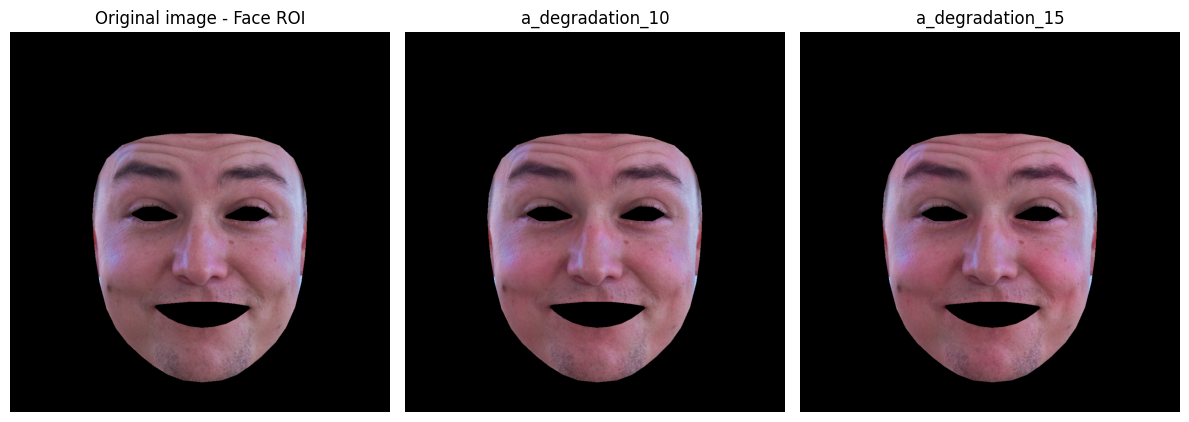

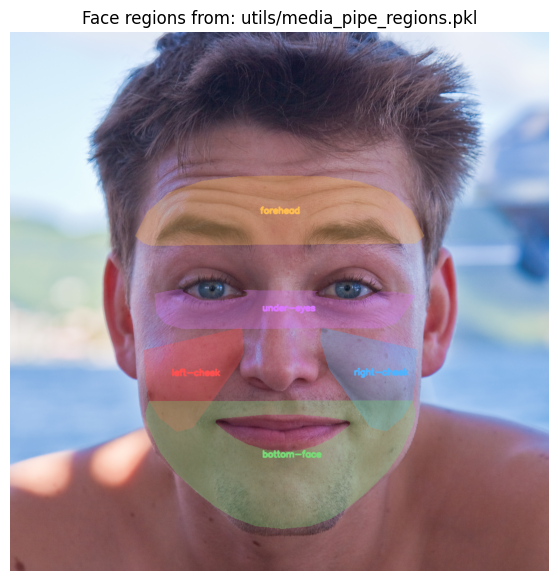

,region,version,tone_evenness_score,tone_local_std_L,tone_range_p90_p10_L,tone_std_a,tone_std_b,evenness_score,local_std_mean,gradient_mean,laplacian_abs_mean,log_abs_mean,gabor_mean_all,gabor_anisotropy_std
0,left-cheek,original_roi,0.1780,4.2651,40.0,3.2963,6.9664,0.0063,4.1992,15.7705,14.5274,2.5911,302.7815,73.8395
1,right-cheek,original_roi,0.1628,5.4403,59.0,3.9945,7.4329,0.0051,5.5021,20.1099,17.0064,3.4056,374.6570,91.9586
2,bottom-face,original_roi,0.2729,7.3273,51.0,2.9783,2.9434,0.0060,7.1513,22.0515,19.6200,3.8289,312.8421,72.3493
3,forehead,original_roi,0.1884,10.8983,88.0,3.9825,5.5931,0.0055,10.6086,29.0180,22.6632,4.6780,336.2047,76.5690
4,under-eyes,original_roi,0.2095,8.5336,68.0,2.7676,5.6189,0.0057,8.4094,26.8165,21.8960,4.4633,327.3285,77.3211
5,left-cheek,a_degradation_10,0.1728,4.2707,40.0,3.6633,6.9719,0.0063,4.2682,16.0559,14.9365,2.6381,302.8523,73.8495
6,right-cheek,a_degradation_10,0.1641,5.4539,59.0,3.8871,7.4351,0.0051,5.5949,20.5128,17.5631,3.4676,375.3854,92.1320
7,bottom-face,a_degradation_10,0.2546,7.3377,50.0,3.5533,2.9517,0.0060,7.2172,22.3695,20.0515,3.8777,313.3507,72.4596
8,forehead,a_degradation_10,0.1805,10.9088,88.0,4.4999,5.5916,0.0055,10.6726,29.3173,23.0919,4.7261,337.0358,76.7195
9,under-eyes,a_degradation_10,0.1972,8.5383,68.0,3.4233,5.6248,0.0057,8.4774,27.0853,22.2173,4.5092,327.7571,77.4008


In [8]:
out_tone_degradation = run_face_tone_degradation_with_regions(
    image_or_path="data/images_wrinkles/00656.png",
    detector=detector,
    cfg=cfg,
    strengths=(0, 10, 15),
    blur_ksize=101,
    local_win=15,
    mask_key="clean_roi",
    region_names=["cheeks", "bottom-face", "forehead", "under-eyes"],
    show=True,
)

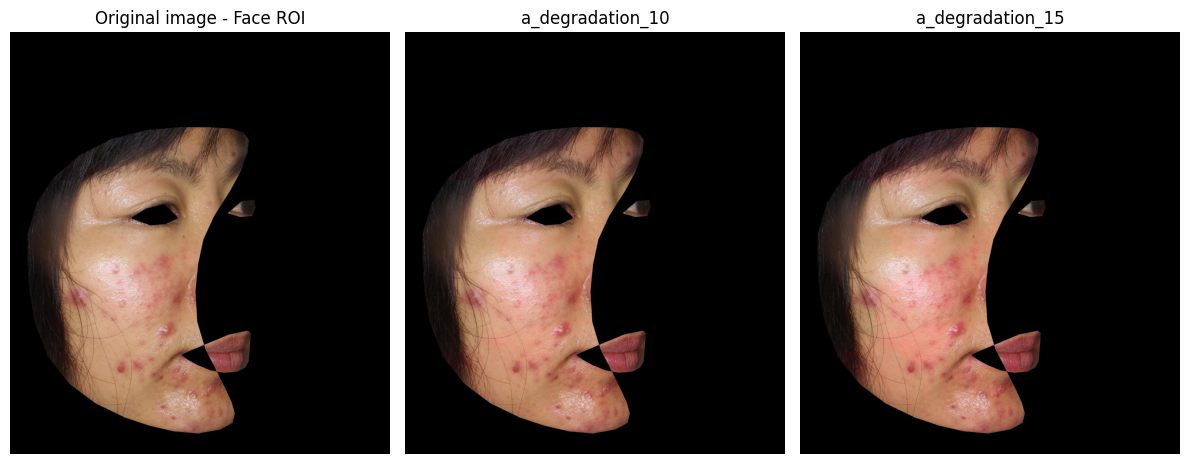

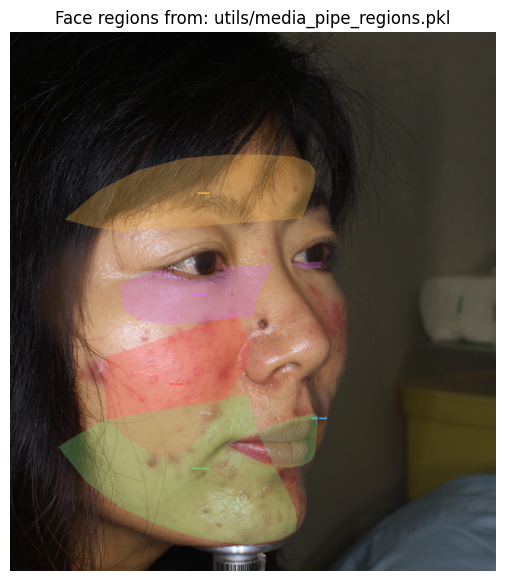

,region,version,tone_evenness_score,tone_local_std_L,tone_range_p90_p10_L,tone_std_a,tone_std_b,evenness_score,local_std_mean,gradient_mean,laplacian_abs_mean,log_abs_mean,gabor_mean_all,gabor_anisotropy_std
0,left-cheek,original_roi,0.1691,6.8570,51.0,4.9975,5.9192,0.0040,7.2846,29.5871,19.9477,5.9121,475.7346,112.5182
1,right-cheek,original_roi,0.2945,12.0055,22.0,2.4690,2.8541,0.0163,11.1660,12.7264,6.3151,2.3220,114.1256,12.6850
2,bottom-face,original_roi,0.1632,8.0221,82.0,5.6922,5.7043,0.0048,8.1751,30.2696,20.1762,6.1535,394.1218,86.8426
3,forehead,original_roi,0.1388,13.0902,123.0,4.3196,9.4725,0.0063,12.0355,49.4139,32.9326,10.4817,281.5619,62.4366
4,under-eyes,original_roi,0.2283,5.9456,48.0,2.6326,4.8797,0.0043,6.1370,23.4532,16.1027,4.6595,449.4443,105.9019
5,left-cheek,a_degradation_10,0.1691,6.8299,51.0,4.9797,5.9427,0.0040,7.3408,29.7680,20.4443,5.9418,476.9002,112.8159
6,right-cheek,a_degradation_10,0.2805,12.0483,22.0,2.8052,2.8938,0.0161,11.2126,13.3353,7.5890,2.4336,114.6720,11.2968
7,bottom-face,a_degradation_10,0.1616,8.0193,82.0,5.8413,5.6880,0.0048,8.2719,30.6530,20.8636,6.2253,394.9565,86.8986
8,forehead,a_degradation_10,0.1362,13.1078,123.0,4.6500,9.4473,0.0063,12.1763,50.0455,33.7979,10.6058,283.2029,62.7978
9,under-eyes,a_degradation_10,0.2242,5.9483,48.0,2.8114,4.8774,0.0043,6.2094,23.7503,16.6518,4.7139,450.8038,106.2160


In [ ]:
out_tone_degradation = run_face_tone_degradation_with_regions(
    image_or_path="data/images_acne/levle2_181.jpg",
    detector=detector,
    cfg=cfg,
    strengths=(0, 10, 15),
    blur_ksize=101,
    local_win=15,
    mask_key="clean_roi",
    region_names=["cheeks", "bottom-face", "forehead", "under-eyes"],
    show=True,
)

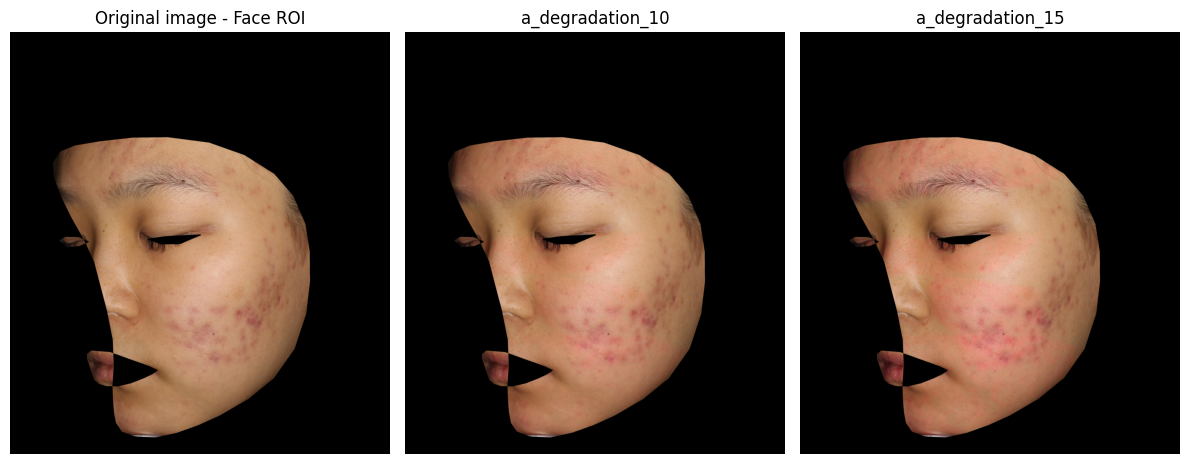

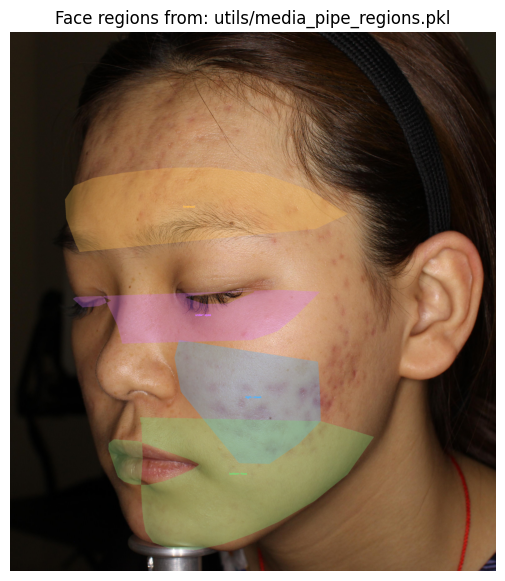

,region,version,tone_evenness_score,tone_local_std_L,tone_range_p90_p10_L,tone_std_a,tone_std_b,evenness_score,local_std_mean,gradient_mean,laplacian_abs_mean,log_abs_mean,gabor_mean_all,gabor_anisotropy_std
0,left-cheek,original_roi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,right-cheek,original_roi,0.2527,5.0992,38.0,2.9573,3.6148,0.0043,5.3778,24.9053,18.1520,4.8118,445.0301,108.4522
2,bottom-face,original_roi,0.2514,4.1482,65.0,2.9354,3.6812,0.0053,4.1634,15.0394,10.1127,2.8652,367.1112,88.7512
3,forehead,original_roi,0.2261,8.5699,75.0,2.8504,4.7562,0.0046,8.7236,36.7388,24.9458,7.4959,410.8525,92.9910
4,under-eyes,original_roi,0.2277,6.2280,86.0,2.5569,4.9792,0.0045,6.3442,26.4514,18.2314,5.1957,422.8254,100.1489
5,left-cheek,a_degradation_10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,right-cheek,a_degradation_10,0.2265,5.1070,38.0,3.9711,3.6177,0.0043,5.4581,25.2220,18.7171,4.8692,446.1330,108.6994
7,bottom-face,a_degradation_10,0.2273,4.1571,65.0,3.8834,3.6692,0.0053,4.2365,15.3254,10.7289,2.9218,367.9380,88.9303
8,forehead,a_degradation_10,0.2201,8.5794,75.0,3.1229,4.7533,0.0045,8.8079,37.0752,25.5203,7.5633,412.0984,93.2321
9,under-eyes,a_degradation_10,0.2215,6.2332,86.0,2.8519,4.9595,0.0045,6.4047,26.7164,18.7537,5.2449,423.8951,100.3474


In [ ]:
out_tone_degradation = run_face_tone_degradation_with_regions(
    image_or_path="data/images_acne/levle1_35.jpg",
    detector=detector,
    cfg=cfg,
    strengths=(0, 10, 15),
    blur_ksize=101,
    local_win=15,
    mask_key="clean_roi",
    region_names=["cheeks", "bottom-face", "forehead", "under-eyes"],
    show=True,
)

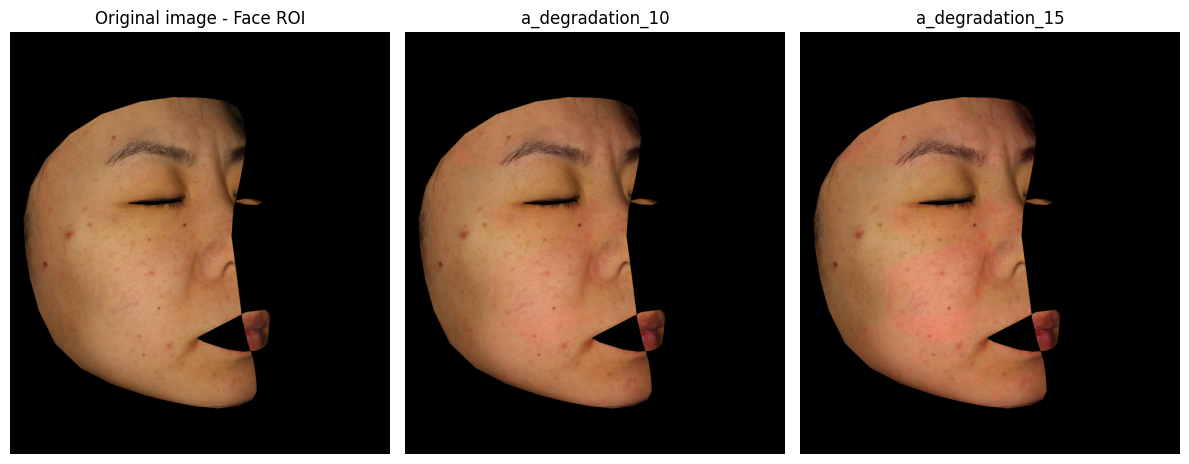

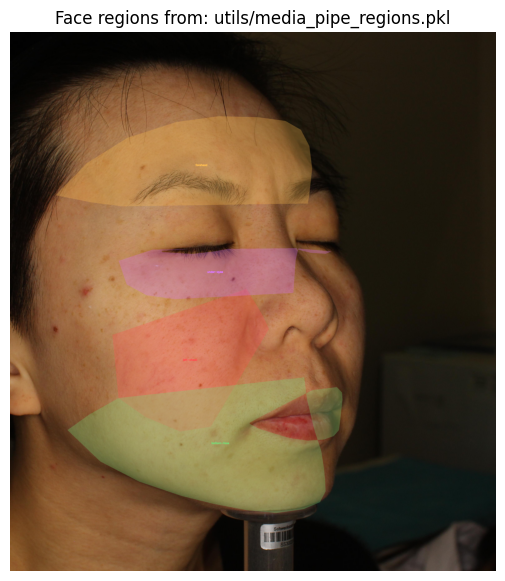

,region,version,tone_evenness_score,tone_local_std_L,tone_range_p90_p10_L,tone_std_a,tone_std_b,evenness_score,local_std_mean,gradient_mean,laplacian_abs_mean,log_abs_mean,gabor_mean_all,gabor_anisotropy_std
0,left-cheek,original_roi,0.2913,2.8522,37.0,2.9495,2.4570,0.0046,3.0099,11.0134,7.0205,2.0747,425.4243,104.0883
1,right-cheek,original_roi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,bottom-face,original_roi,0.2283,3.2151,70.0,3.2578,4.2558,0.0055,3.1889,9.8595,6.3515,1.8157,355.5281,86.3934
3,forehead,original_roi,0.1967,5.3015,70.0,3.0810,5.9924,0.0059,5.1069,17.6532,10.8162,3.5740,325.9502,76.0629
4,under-eyes,original_roi,0.2631,3.6026,40.0,2.7683,3.4550,0.0052,3.6237,12.4894,8.0515,2.4014,374.0482,90.4856
5,left-cheek,a_degradation_10,0.2780,2.8631,37.0,3.3128,2.4588,0.0046,3.0880,11.3057,7.6682,2.1294,426.2263,104.2854
6,right-cheek,a_degradation_10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,bottom-face,a_degradation_10,0.2188,3.2286,70.0,3.6967,4.2358,0.0055,3.2786,10.2109,7.0727,1.8847,356.0367,86.5131
8,forehead,a_degradation_10,0.1928,5.3200,71.0,3.3169,5.9887,0.0059,5.2033,18.0348,11.5302,3.6569,326.6524,76.1893
9,under-eyes,a_degradation_10,0.2561,3.6133,40.0,3.0059,3.4474,0.0052,3.6925,12.7395,8.5832,2.4496,374.4996,90.5858


In [ ]:
out_tone_degradation = run_face_tone_degradation_with_regions(
    image_or_path="data/images_acne/levle0_169.jpg",
    detector=detector,
    cfg=cfg,
    strengths=(0, 10, 15),
    blur_ksize=101,
    local_win=15,
    mask_key="clean_roi",
    region_names=["cheeks", "bottom-face", "forehead", "under-eyes"],
    show=True,
)

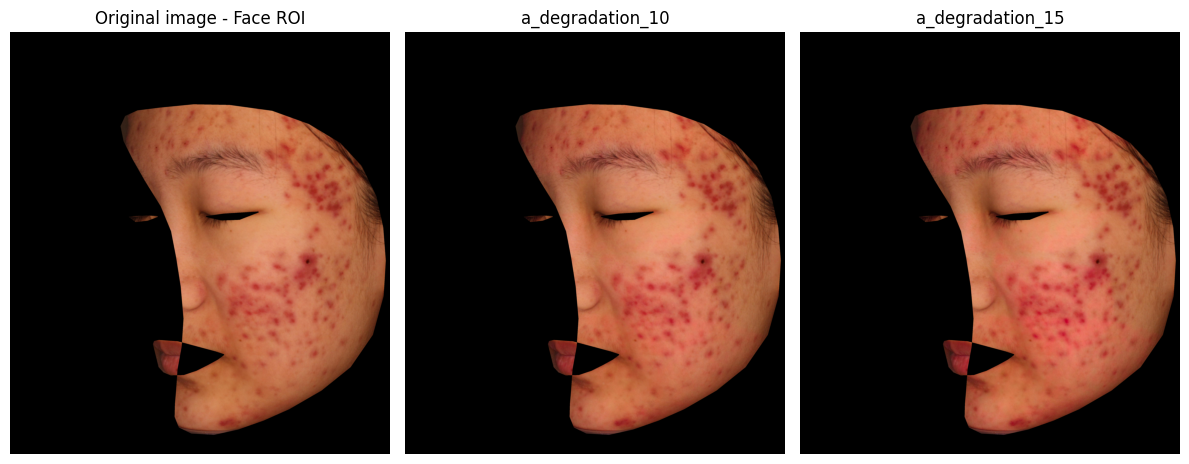

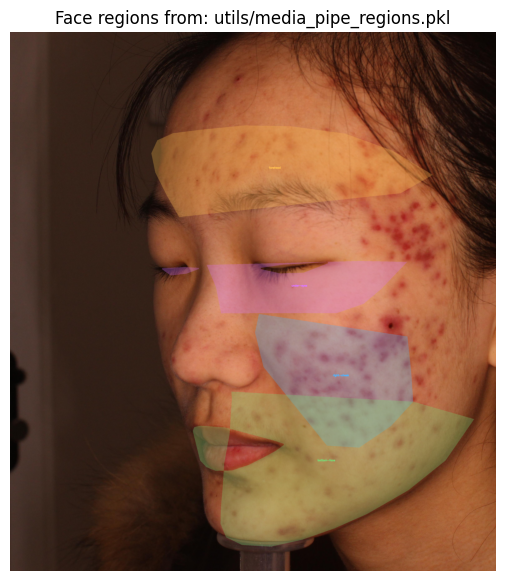

,region,version,tone_evenness_score,tone_local_std_L,tone_range_p90_p10_L,tone_std_a,tone_std_b,evenness_score,local_std_mean,gradient_mean,laplacian_abs_mean,log_abs_mean,gabor_mean_all,gabor_anisotropy_std
0,left-cheek,original_roi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,right-cheek,original_roi,0.2227,2.5557,35.0,5.8012,1.9558,0.0053,2.8251,7.9674,5.0473,1.3013,373.6523,91.4281
2,bottom-face,original_roi,0.2067,2.8437,61.0,4.1782,4.3503,0.0059,2.8781,8.0050,5.2341,1.3969,332.4276,80.7714
3,forehead,original_roi,0.1707,4.0286,69.0,4.8577,5.9420,0.0058,4.0816,10.8609,6.0428,1.8410,334.4227,81.3648
4,under-eyes,original_roi,0.2483,2.7192,60.0,2.7182,4.0110,0.0048,2.7134,7.4752,5.0286,1.3455,410.0766,99.8121
5,left-cheek,a_degradation_10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,right-cheek,a_degradation_10,0.2178,2.5686,35.0,6.0217,1.9581,0.0053,2.9854,8.4719,5.8812,1.4014,371.6030,90.9316
7,bottom-face,a_degradation_10,0.1909,2.8544,61.0,5.0847,4.3341,0.0059,2.9906,8.3970,5.9572,1.4792,330.9575,80.4013
8,forehead,a_degradation_10,0.1690,4.0397,69.0,5.0096,5.9197,0.0058,4.1844,11.2248,6.7852,1.9152,333.5709,81.1545
9,under-eyes,a_degradation_10,0.2436,2.7325,60.0,2.8932,4.0070,0.0048,2.7959,7.7703,5.6016,1.4125,410.2581,99.8563


In [ ]:
out_tone_degradation = run_face_tone_degradation_with_regions(
    image_or_path="data/images_acne/levle3_80.jpg",
    detector=detector,
    cfg=cfg,
    strengths=(0, 10, 15),
    blur_ksize=101,
    local_win=15,
    mask_key="clean_roi",
    region_names=["cheeks", "bottom-face", "forehead", "under-eyes"],
    show=True,
)

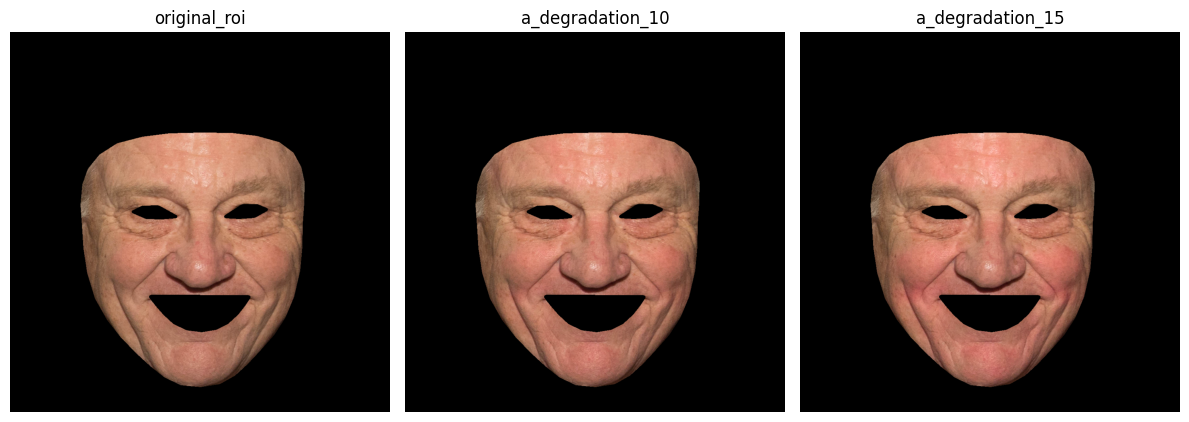

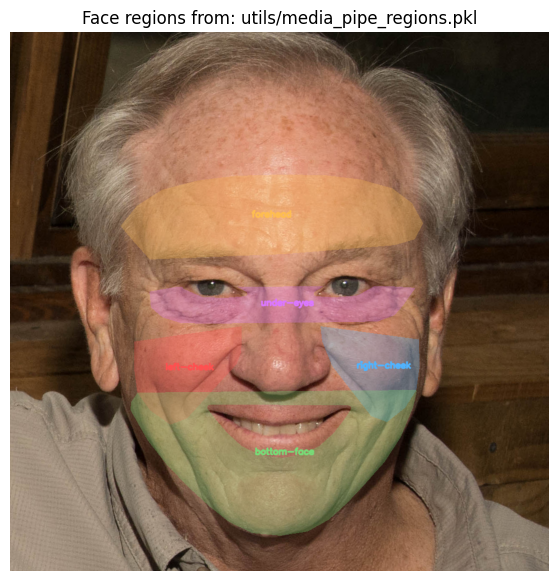

,region,version,tone_evenness_score,tone_local_std_L,tone_range_p90_p10_L,tone_std_a,tone_std_b,evenness_score,local_std_mean,gradient_mean,laplacian_abs_mean,log_abs_mean,gabor_mean_all,gabor_anisotropy_std
0,left-cheek,original_roi,0.2506,8.3923,59.0,4.3840,2.2608,0.0049,8.4921,30.4966,20.5344,5.4425,386.5044,96.0931
1,right-cheek,original_roi,0.2225,7.8058,71.0,4.5995,3.1638,0.0051,7.8371,27.2237,17.9451,4.8204,368.9656,91.1623
2,bottom-face,original_roi,0.2435,11.7883,60.0,3.9763,2.9278,0.0054,11.5204,33.0172,20.8716,5.8540,345.8455,79.1478
3,forehead,original_roi,0.2736,7.2776,54.0,3.4309,2.4702,0.0043,7.5009,25.6946,18.3876,4.7010,449.4102,107.5988
4,under-eyes,original_roi,0.3086,11.9978,42.0,3.0183,1.9606,0.0046,12.2362,38.5205,23.9055,7.1363,405.6969,91.6227
5,left-cheek,a_degradation_10,0.2427,8.3943,59.0,4.6738,2.2584,0.0049,8.5616,30.8118,20.8536,5.5033,386.9523,96.2856
6,right-cheek,a_degradation_10,0.2203,7.8134,71.0,4.7151,3.1522,0.0051,7.9010,27.5249,18.3387,4.8739,369.2933,91.2169
7,bottom-face,a_degradation_10,0.2334,11.7940,60.0,4.3767,2.9219,0.0054,11.6039,33.3915,21.3314,5.9226,346.4493,79.2668
8,forehead,a_degradation_10,0.2598,7.2829,54.0,3.8574,2.4726,0.0042,7.5718,25.9373,18.7808,4.7474,450.1665,107.7797
9,under-eyes,a_degradation_10,0.2896,12.0047,42.0,3.4873,1.9629,0.0046,12.3064,38.7718,24.2327,7.1862,406.2453,91.6017


In [ ]:
out_tone_degradation = run_face_tone_degradation_with_regions(
    image_or_path="data/images_wrinkles/00144.png",
    detector=detector,
    cfg=cfg,
    strengths=(0, 10, 15),
    blur_ksize=101,
    local_win=15,
    mask_key="clean_roi",
    region_names=["cheeks", "bottom-face", "forehead", "under-eyes"],
    show=True,
)

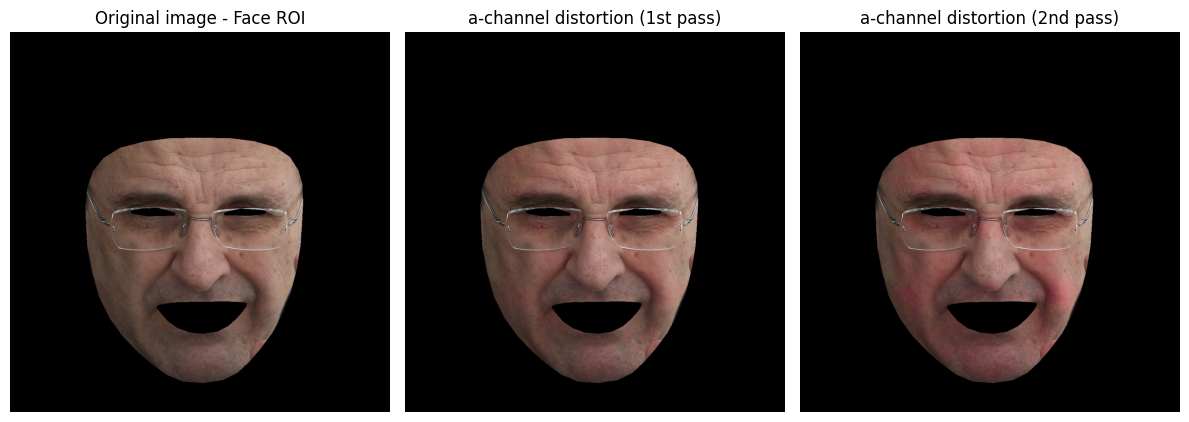

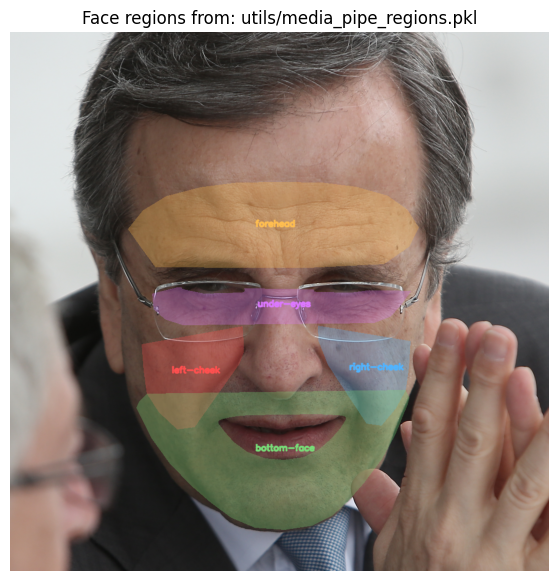

,region,version,tone_evenness_score,tone_local_std_L,tone_range_p90_p10_L,tone_std_a,tone_std_b,evenness_score,local_std_mean,gradient_mean,laplacian_abs_mean,log_abs_mean,gabor_mean_all,gabor_anisotropy_std
0,left-cheek,original_roi,0.3088,6.0935,43.0000,3.1252,1.8483,0.0076,5.7494,18.4087,13.6791,3.4958,246.1991,49.5398
1,right-cheek,original_roi,0.2614,8.9145,76.0000,3.7269,2.5521,0.0052,8.8517,28.9860,22.1665,5.3991,358.4558,74.0548
2,bottom-face,original_roi,0.3248,7.1085,57.0000,2.4304,2.1886,0.0084,6.5916,19.0851,13.3409,3.3219,223.2216,50.8749
3,forehead,original_roi,0.3485,8.0677,71.0000,2.1204,2.0332,0.0052,7.9737,28.0814,20.5447,5.1816,358.5159,82.7745
4,under-eyes,original_roi,0.2840,11.2404,73.0000,2.5748,3.0290,0.0067,10.6778,35.4435,25.3714,6.5892,273.1624,49.2006
5,left-cheek,a_degradation_11,0.2922,6.1069,43.0000,3.5206,1.8622,0.0076,5.8114,18.7277,14.3152,3.5580,247.0902,49.6330
6,right-cheek,a_degradation_11,0.2448,8.9264,76.0000,4.2988,2.5549,0.0052,8.9516,29.3889,22.7646,5.4752,359.6344,74.1883
7,bottom-face,a_degradation_11,0.2923,7.1251,57.0000,3.1852,2.1953,0.0083,6.6525,19.3696,13.9515,3.3693,224.1849,51.0693
8,forehead,a_degradation_11,0.3201,8.0836,71.0000,2.6892,2.0319,0.0052,8.0817,28.5576,21.0868,5.2718,359.9644,83.0255
9,under-eyes,a_degradation_11,0.2622,11.2456,74.0000,3.2194,3.0345,0.0066,10.7678,35.8309,25.9613,6.6663,274.2053,49.1612


In [ ]:
out_tone_degradation = run_face_tone_degradation_with_regions(
    image_or_path="data/images/00000/00021.png",
    detector=detector,
    cfg=cfg,
    strengths=(0, 11, 17),
    blur_ksize=101,
    local_win=15,
    mask_key="clean_roi",
    region_names=["cheeks", "bottom-face", "forehead", "under-eyes"],
    show=True,
)

## **Calculate tone evenness across whole dataset**

In [48]:
folder = "data/images_wrinkles"

all_rows = []
failed = []

strengths = [0, 11, 17]

for fname in tqdm(sorted(os.listdir(folder))):
    if not fname.lower().endswith((".png", ".jpg", ".jpeg")):
        continue

    path = os.path.join(folder, fname)

    out_regions = run_face_tone_degradation_with_regions(
        image_or_path=path,
        detector=detector,
        cfg=cfg,
        strengths=strengths,
        blur_ksize=101,
        local_win=15,
        mask_key="clean_roi",
        region_landmarks_path="models/лендмаркс.пікл",
        region_names=["cheeks", "bottom-face", "forehead", "under-eyes"],
        show=False,
    )

    if out_regions["status"] != "ok":
        failed.append((fname, out_regions["status"]))
        continue

    df = out_regions["region_metrics_df"].copy()
    df["image"] = fname

    # беремо тільки evenness_score
    all_rows.append(
        df[["image", "region", "version", "tone_evenness_score"]]
    )

scores_df = pd.concat(all_rows, ignore_index=True)

display(scores_df.head())
print("Failed images:", len(failed))
failed[:10]

100%|██████████| 1000/1000 [1:50:13<00:00,  6.61s/it]


,image,region,version,tone_evenness_score
0,00001.png,left-cheek,original_roi,0.280403
1,00001.png,right-cheek,original_roi,0.246866
2,00001.png,bottom-face,original_roi,0.246249
3,00001.png,forehead,original_roi,0.158368
4,00001.png,under-eyes,original_roi,0.202176


Failed images: 0


[]

In [49]:
region_mean_scores = (
    scores_df
    .groupby(["region", "version"], as_index=False)["tone_evenness_score"]
    .mean()
)

display(region_mean_scores.round(4))

,region,version,tone_evenness_score
0,bottom-face,a_degradation_11,0.2199
1,bottom-face,a_degradation_17,0.2007
2,bottom-face,original_roi,0.2330
3,forehead,a_degradation_11,0.2023
4,forehead,a_degradation_17,0.1929
5,forehead,original_roi,0.2113
6,left-cheek,a_degradation_11,0.2346
7,left-cheek,a_degradation_17,0.2167
8,left-cheek,original_roi,0.2427
9,right-cheek,a_degradation_11,0.2313


In [51]:
scores_df.to_csv("face_tone_degradation_scores_toneee.csv", index=False)

## **Tone evenness across facial regions**

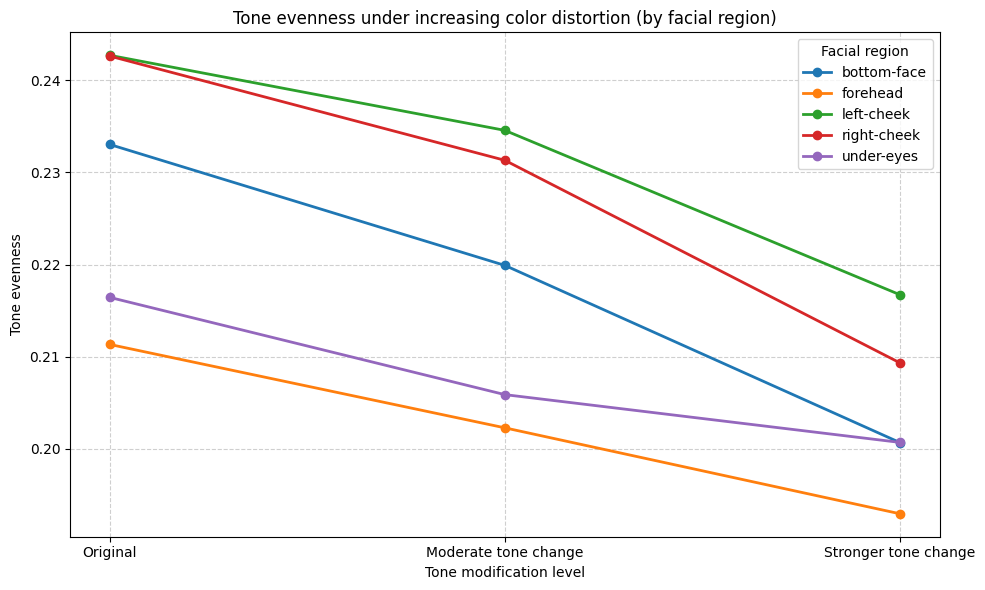

In [53]:
version_order = [
    "original_roi",
    "a_degradation_11",
    "a_degradation_17",
]

version_labels = {
    "original_roi": "Original",
    "a_degradation_11": "Moderate tone change",
    "a_degradation_17": "Stronger tone change",
}

plt.figure(figsize=(10, 6))

for region in region_mean_scores["region"].unique():
    part = (
        region_mean_scores[region_mean_scores["region"] == region]
        .set_index("version")
        .loc[version_order]
        .reset_index()
    )

    # красиві підписи
    part["version_label"] = part["version"].map(version_labels)

    plt.plot(
        part["version_label"],
        part["tone_evenness_score"],
        marker="o",
        linewidth=2,
        label=region
    )

plt.xlabel("Tone modification level")
plt.ylabel("Tone evenness")
plt.title("Tone evenness under increasing color distortion (by facial region)")

plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(title="Facial region")
plt.tight_layout()
plt.show()

## **Tone evenness at global level**

,version,tone_evenness_score,version_label
0,original_roi,0.2292,Original
1,a_degradation_11,0.2187,Moderate tone change
2,a_degradation_17,0.2040,Stronger tone change


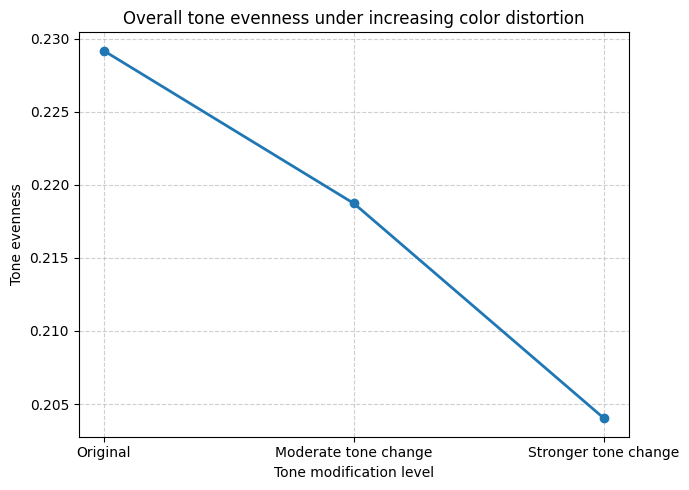

In [56]:
version_order = [
    "original_roi",
    "a_degradation_11",
    "a_degradation_17",
]

version_labels = {
    "original_roi": "Original",
    "a_degradation_11": "Moderate tone change",
    "a_degradation_17": "Stronger tone change",
}

# агрегуємо
global_mean_scores = (
    scores_df
    .groupby("version", as_index=False)["tone_evenness_score"]
    .mean()
)

# правильний порядок
global_mean_scores = (
    global_mean_scores
    .set_index("version")
    .loc[version_order]
    .reset_index()
)

# красиві підписи
global_mean_scores["version_label"] = global_mean_scores["version"].map(version_labels)

display(global_mean_scores.round(4))

# графік
plt.figure(figsize=(7, 5))

plt.plot(
    global_mean_scores["version_label"],
    global_mean_scores["tone_evenness_score"],
    marker="o",
    linewidth=2
)

plt.xlabel("Tone modification level")
plt.ylabel("Tone evenness")
plt.title("Overall tone evenness under increasing color distortion")

plt.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()